In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors

import numpy as np

import cartopy.crs as ccrs
import cartopy as cart
import cmocean
import torch
import torch.nn as nn
import torch.utils.data as data
import torch_geometric
from torch.nn import Sequential as Seq, Linear, ReLU
from matplotlib.animation import FuncAnimation

import sys

sys.path.append("../src/")
from models.vit import *
from utils.data_utils import *
from utils.climate_utils import *
from utils.subgrid_utils import *
from utils.train_utils import *
from utils.eval_utils import *

import numpy.fft as fft
import sys
import matplotlib.ticker as ticker

In [2]:
exp_num_in = "3"
exp_num_extra = "12"
exp_num_out = "2"


mse = torch.nn.MSELoss()

region = "Gulf_Stream_Ext"
network = "U_net"

interval = 1

N_samples = 4000
N_val = 200
N_test = 3000

Nb = 4

factor = 10

hist = 0

lag = 1

steps = 8

if len(sys.argv) > 4:
    n_cond = int((len(sys.argv) - 4) / 2)

str_video = ""

try:
    for i in range(n_cond):
        if type(globals()[sys.argv[int(4 + i * 2)]]) == str:
            temp = str(sys.argv[int(5 + i * 2)])
            exec(sys.argv[int(4 + i * 2)] + "= temp")
            if sys.argv[int(4 + i * 2)] == "network":
                continue
            str_video += "_" + sys.argv[int(4 + i * 2)] + "_" + sys.argv[int(5 + i * 2)]
        elif type(globals()[sys.argv[int(4 + i * 2)]]) == int:
            exec(
                sys.argv[int(4 + i * 2)] + "=" + "int(" + sys.argv[int(5 + i * 2)] + ")"
            )
            str_video += "_" + sys.argv[int(4 + i * 2)] + "_" + sys.argv[int(5 + i * 2)]
    print(str_video)
except:
    print("no cond")


if region == "Kuroshio":
    lat = [15, 41]
    lon = [-215, -185]
elif region == "Kuroshio_Ext":
    lat = [5, 50]
    lon = [-250, -175]
elif region == "Gulf_Stream":
    lat = [25, 50]
    lon = [-70, -35]
elif region == "Gulf_Stream_Ext":
    lat = [27, 50]
    lon = [-82, -35]
elif region == "Tropics":
    lat = [-5, 25]
    lon = [-95, -65]
elif region == "Tropics_Ext":
    lat = [-5, 25]
    lon = [-115, -45]
elif region == "South_America":
    lat = [-60, -30]
    lon = [-70, -35]
elif region == "Africa":
    lat = [-50, -20]
    lon = [5, 45]
elif region == "Quiescent":
    lat = [-42.5, -17.5]
    lon = [-155, -120]
elif region == "Quiescent_Ext":
    lat = [-55, -10]
    lon = [-170, -110]
elif region == "Pacific":
    lat = [-35, 35]
    lon = [-230, -80]
elif region == "Indian":
    lat = [-30, 28]
    lon = [30, 79]
elif region == "Africa_Ext":
    lat = [-55, -15]
    lon = [-5, 55]

s_train = lag * hist
e_train = s_train + N_samples * interval
e_test = e_train + interval * N_val


device = "cpu"


inpt_dict = {
    "1": ["um", "vm"],
    "2": ["um", "vm", "ur", "vr"],
    "3": ["um", "vm", "Tm"],
    "4": ["um", "vm", "ur", "vr", "Tm", "Tr"],
    "5": ["ur", "vr"],
    "6": ["ur", "vr", "Tr"],
    "7": ["Tm"],
    "8": ["Tm", "Tr"],
    "9": ["u", "v"],
    "10": ["u", "v", "T"],
    "11": ["tau_u", "tau_v"],
}
extra_dict = {
    "1": ["ur", "vr"],
    "2": ["ur", "vr", "Tm"],
    "3": ["Tm"],
    "4": ["ur", "vr", "Tm", "Tr"],
    "5": [],
    "6": ["um", "vm"],
    "7": ["um", "vm", "Tm"],
    "8": ["um", "vm", "Tm", "Tr"],
    "9": ["ur", "vr", "tau_u", "tau_v"],
    "10": ["tau_u", "tau_v"],
    "11": ["t_ref"],
    "12": ["tau_u", "tau_v", "t_ref"],
}
out_dict = {
    "1": ["um", "vm"],
    "2": ["um", "vm", "Tm"],
    "3": ["ur", "vr"],
    "4": ["ur", "vr", "Tr"],
    "5": ["u", "v"],
    "6": ["u", "v", "T"],
}


grids = xr.open_dataset("/scratch/as15415/Data/CM2x_grids/Grid_cm25_Vertices.nc")
if "global" in region:
    grids = coarse_grid(grids, factor)

else:
    grids = grids.sel(
        {"yu_ocean": slice(lat[0], lat[1]), "xu_ocean": slice(lon[0], lon[1])}
    )


area = torch.from_numpy(grids["area_C"].to_numpy()).to(device=device)
dx = grids["dxu"].to_numpy()
dy = grids["dyu"].to_numpy()


inputs = inpt_dict[exp_num_in]
extra_in = extra_dict[exp_num_extra]
outputs = out_dict[exp_num_out]

str_in = "".join([i + "_" for i in inputs])
str_ext = "".join([i + "_" for i in extra_in])
str_out = "".join([i + "_" for i in outputs])

print("inputs: " + str_in)
print("extra inputs: " + str_ext)
print("outputs: " + str_out)

N_atm = len(extra_in)
N_in = len(inputs)
N_extra = N_atm + N_in
N_out = len(outputs)

num_in = int((hist + 1) * N_in + N_extra)

if "global" in region:
    inputs, extra_in, outputs = gen_data_global(inputs, extra_in, outputs, lag)
else:
    inputs, extra_in, outputs = inputs, extra_in, outputs = gen_data_025_lateral(
        inputs, extra_in, outputs, lag, lat, lon, Nb, filter_T=True
    )


wet = xr.zeros_like(inputs[0][0])
# inputs[0][0,12,12] = np.nan
for data in inputs:
    wet += np.isnan(data[0])
wet_nan = xr.where(wet != 0, np.nan, 1).to_numpy()
wet = xr.where(wet == 0, np.nan, 0)
wet = np.isnan(wet)
wet = np.nan_to_num(wet.to_numpy())
wet = torch.from_numpy(wet).type(torch.float32).to(device=device)
wet_bool = np.array(wet.cpu()).astype(bool)

time_vec = inputs[0].time.data

no cond
inputs: um_vm_Tm_
extra inputs: tau_u_tau_v_t_ref_
outputs: um_vm_Tm_


/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:682: UserWarning: rename 'lat' to 'yu_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yu_ocean","lon":"xu_ocean"})
/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:682: UserWarning: rename 'lon' to 'xu_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yu_ocean","lon":"xu_ocean"})


In [3]:
test_data = torch.load(
    "/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/data/test_data_{0}.pt".format(
        "steps_"
        + str(steps)
        + "_"
        + region
        + "_in_"
        + str_in
        + "ext_"
        + str_ext
        + "N_samples_"
        + str(N_samples)
    )
)

time_test = time_vec[e_test : (e_test + lag * N_test)]

mean_out = test_data.norm_vals["m_out"]
std_out = test_data.norm_vals["s_out"]
mean_in = test_data.norm_vals["m_in"]
std_in = test_data.norm_vals["s_in"]

In [4]:
def get_stats(
    zarr_path,
    region,
    step,
    rand_int,
    str_in,
    str_ext,
    test_data,
    area,
    wet_bool,
    N_mean,
    lag,
    lam,
):
    extra_dict = {
        "5": [],
        "10": ["tau_u", "tau_v"],
        "11": ["t_ref"],
        "12": ["tau_u", "tau_v", "t_ref"],
    }
    str_ext = "".join([i + "_" for i in extra_dict[lam]])
    model_pred_atm = (
        xr.open_zarr(
            zarr_path
            + "/Pred_lateral_Fast_Data_025_"
            + region
            + "_in_"
            + str_in
            + "ext_"
            + str_ext
            + "N_samples_"
            + str(4000)
            + "_rand_seed_"
            + str(rand_int)
            + ".zarr"
        )
        .sel(time=slice(0, N_mean))
        .to_array()
        .to_numpy()
        .squeeze()
    )
    mean_atm, auto_mean = compute_mean(
        N_mean, test_data, model_pred_atm, area.cpu(), wet_bool
    )
    var_atm, auto_var = compute_var(
        N_mean, test_data, model_pred_atm, area.cpu(), wet_bool
    )
    rmse_atm, auto_rmse = compute_rmse(
        np.min((500, N_mean)), test_data, model_pred_atm, area.cpu(), wet_bool
    )
    corrs_atm, auto_corrs = compute_corrs(
        np.min((500, N_mean)), test_data, model_pred_atm, wet_bool
    )
    KE, auto_KE = compute_KE(N_mean, test_data, model_pred_atm, area, wet_bool)
    freqs, FFT, auto_FFT = compute_time_spec(N_mean, auto_mean, mean_atm, lag)

    return (
        model_pred_atm,
        mean_atm,
        auto_mean,
        rmse_atm,
        auto_rmse,
        corrs_atm,
        auto_corrs,
        KE,
        auto_KE,
        freqs,
        FFT,
        auto_FFT,
        var_atm,
        auto_var,
    )

In [5]:
def get_spred(
    zarr_path,
    region,
    step,
    num_IC,
    str_in,
    str_ext,
    test_data,
    area,
    wet_bool,
    N_mean,
    lag,
    lam,
):
    mean = np.zeros((num_IC, N_mean, 3))
    var = np.zeros((num_IC, N_mean, 3))
    KE = np.zeros((num_IC, N_mean))
    rmse = np.zeros((num_IC, np.min((500, N_mean)), 3))
    corrs = np.zeros((num_IC, np.min((500, N_mean)), 3))
    FFTs = np.zeros((num_IC, int(N_mean / 2 + 1), 3))

    for i in range(0, num_IC):
        (
            out,
            mean_1,
            out,
            rmse_1,
            out,
            corrs_1,
            out,
            KE_1,
            out,
            freqs,
            FFT_1,
            out,
            var_1,
            out,
        ) = get_stats(
            zarr_path,
            region,
            step,
            i + 1,
            str_in,
            str_ext,
            test_data,
            area,
            wet_bool,
            N_mean,
            lag,
            lam,
        )
        KE[i] = KE_1
        mean[i] = mean_1
        rmse[i] = rmse_1
        corrs[i] = corrs_1
        FFTs[i] = FFT_1
        var[i] = var_1
    return mean, rmse, corrs, KE, FFTs, freqs, var

In [6]:
short_model_name = "ViT_best_steps_steps_8_"
full_model_name = (
    short_model_name
    + region
    + "_Test_in_"
    + str_in
    + "ext_"
    + str_ext
    + "_out"
    + str_in
    + "N_train_"
    + str(N_samples)
    + "_Lateral_Data_025_no_smooth"
)
vit_path = "/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/" + full_model_name
unet_path = "/scratch/as15415/Emulation/Preds"

In [7]:
mean_vit, rmse_vit, corrs_vit, KE_vit, FFTs_vit, freqs, var_vit = get_spred(
    vit_path, region, 4, 3, str_in, str_ext, test_data, area, wet_bool, 3000, lag, "12"
)
(
    model_pred_vit,
    m_vit,
    auto_mean,
    r_vit,
    auto_rmse,
    c_vit,
    auto_corrs,
    K_vit,
    auto_KE,
    freqs,
    F_vit,
    auto_FFT,
    v_vit,
    auto_var,
) = get_stats(
    vit_path, region, 4, 1, str_in, str_ext, test_data, area, wet_bool, 3000, lag, "12"
)

In [8]:
mean_unet, rmse_unet, corrs_unet, KE_unet, FFTs_unet, _, var_unet = get_spred(
    unet_path, region, 4, 3, str_in, str_ext, test_data, area, wet_bool, 3000, lag, "12"
)
model_pred_unet, m_unet, _, r_unet, _, c_unet, _, K_unet, _, _, F_unet, _, v_unet, _ = (
    get_stats(
        unet_path,
        region,
        4,
        1,
        str_in,
        str_ext,
        test_data,
        area,
        wet_bool,
        3000,
        lag,
        "12",
    )
)

In [9]:
(
    model_pred_unet,
    m_unet,
    auto_mean_unet,
    r_unet,
    auto_rmse_unet,
    c_unet,
    auto_corrs_unet,
    K_unet,
    auto_KE_unet,
    _,
    F_unet,
    auto_FFT_unet,
    v_unet,
    auto_var_unet,
) = get_stats(
    unet_path, region, 4, 1, str_in, str_ext, test_data, area, wet_bool, 3000, lag, "12"
)

In [10]:
assert (auto_mean == auto_mean_unet).all()
assert (auto_rmse == auto_rmse_unet).all()
assert (auto_corrs == auto_corrs_unet).all()
assert (auto_KE == auto_KE_unet).all()
assert (auto_FFT == auto_FFT_unet).all()
assert (auto_var == auto_var_unet).all()

In [11]:
N = 5

plt.style.use("bmh")

clist_1 = [cmocean.cm.thermal(i / (N - 0.5)) for i in range(1, N)]
clist_2 = ["#d7191c", "#abd9e9", "#2c7bb6", "#fdae61"]
clist_3 = ["#91B59A", "#D6A922", "#1E88E5", "#A00B41"]
clist = clist_3

In [12]:
def plot_time_spec(plt_index, index, legend=True):
    T_plot = 200

    N_int = int(T_plot)
    N_true = min(N_test, N_int)

    var_list = {
        "1": r"$\widehat{\bar{v}} ~~\mathrm{(m/s)}$",
        "0": r"$\widehat{\bar{u}} ~~\mathrm{(m/s)}$",
        "2": r"$\widehat{\bar{T}} ~ (^\circ C)$",
    }

    axs[plt_index].semilogx(
        freqs[:N_int], auto_FFT[:N_int, index], "--k", label="CM2.6", zorder=5
    )

    axs[plt_index].plot(
        freqs[:N_int],
        FFTs_unet.mean(axis=0)[:N_int, index],
        color=clist[2],
        label=r"Unet($\mathbf{u},\tau_u,\tau_v,T_{\mathrm{atm}}$)",
    )
    axs[plt_index].fill_between(
        freqs[:N_int],
        FFTs_unet.mean(axis=0)[:N_int, index] - FFTs_unet.std(axis=0)[:N_int, index],
        FFTs_unet.mean(axis=0)[:N_int, index] + FFTs_unet.std(axis=0)[:N_int, index],
        ls="--",
        color=clist[2],
        alpha=0.25,
    )

    axs[plt_index].plot(
        freqs[:N_int],
        FFTs_vit.mean(axis=0)[:N_int, index],
        color=clist[3],
        label=r"ViT($\mathbf{u},\tau_u,\tau_v,T_{\mathrm{atm}}$)",
    )
    axs[plt_index].fill_between(
        freqs[:N_int],
        FFTs_vit.mean(axis=0)[:N_int, index] - FFTs_vit.std(axis=0)[:N_int, index],
        FFTs_vit.mean(axis=0)[:N_int, index] + FFTs_vit.std(axis=0)[:N_int, index],
        ls="--",
        color=clist[3],
        alpha=0.25,
    )

    axs[plt_index].set_ylabel(r"" + var_list[str(index)])
    axs[plt_index].set_xlabel("Frequency (1/day)")

    axs[plt_index].set_xlim([0, freqs[T_plot]])
    axs[plt_index].set_ylim([0, auto_FFT[1:N_int, index].max() * 2])

    if legend:
        axs[plt_index].legend(ncol=1, loc="upper right")

    # plt.tight_layout()


def plot_var(plt_index, index):
    T_plot = 1098

    N_int = int(T_plot / lag)
    N_true = min(N_test, N_int)

    var_list = {
        "1": r"$\mathrm{Var}(\bar{v})$",
        "0": r"$\mathrm{Var}(\bar{u})$",
        "2": r"$\mathrm{Var}(\bar{T})$",
    }

    axs[plt_index].plot(
        (np.arange(N_int) * lag) / 366,
        auto_var[:N_int, index],
        "--k",
        label="CM2.6",
        zorder=5,
    )

    axs[plt_index].plot(
        (np.arange(N_int) * lag) / 366,
        var_unet.mean(axis=0)[:N_int, index],
        color=clist[2],
        label=r"Unet($\mathbf{u},\tau_u,\tau_v,T_{ref}$)",
    )
    axs[plt_index].fill_between(
        (np.arange(N_int) * lag) / 366,
        var_unet.mean(axis=0)[:N_int, index] - var_unet.std(axis=0)[:N_int, index],
        var_unet.mean(axis=0)[:N_int, index] + var_unet.std(axis=0)[:N_int, index],
        ls="--",
        color=clist[2],
        alpha=0.25,
    )

    axs[plt_index].plot(
        (np.arange(N_int) * lag) / 366,
        var_vit.mean(axis=0)[:N_int, index],
        color=clist[3],
        label=r"ViT($\mathbf{u},\tau_u,\tau_v,T_{ref}$)",
    )
    axs[plt_index].fill_between(
        (np.arange(N_int) * lag) / 366,
        var_vit.mean(axis=0)[:N_int, index] - var_vit.std(axis=0)[:N_int, index],
        var_vit.mean(axis=0)[:N_int, index] + var_vit.std(axis=0)[:N_int, index],
        ls="--",
        color=clist[3],
        alpha=0.25,
    )

    axs[plt_index].set_ylabel(r"" + var_list[str(index)])
    axs[plt_index].set_xlabel("Time (years)")

    axs[plt_index].set_xlim([0, T_plot / 366])
    axs[plt_index].yaxis.set_major_formatter(
        ticker.ScalarFormatter(useMathText=True, useOffset=False)
    )
    axs[plt_index].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    axs[plt_index].xaxis.set_major_locator(
        ticker.MultipleLocator(base=0.5)
    )  # Adjust base as needed


#     axs[plt_index].legend(ncol=2)


def plot_mean(plt_index, index):

    T_plot = 3000

    N_int = int(T_plot / lag)
    N_true = min(N_test, N_int)

    var_list = {
        "1": r"$\bar{v}~~\mathrm{(m/s)}$",
        "0": r"$\bar{u}~~\mathrm{(m/s)}$",
        "2": r"$\bar{T} ~ (^\circ C)$",
    }

    axs[plt_index].plot(
        (np.arange(N_int) * lag) / 366,
        auto_mean[:N_int, index],
        "--k",
        label="CM2.6",
        zorder=5,
    )

    axs[plt_index].plot(
        (np.arange(N_int) * lag) / 366,
        mean_unet.mean(axis=0)[:N_int, index],
        color=clist[2],
        label=r"Unet($\mathbf{u},\tau_u,\tau_v,T_{ref}$)",
    )
    axs[plt_index].fill_between(
        (np.arange(N_int) * lag) / 366,
        mean_unet.mean(axis=0)[:N_int, index] - mean_unet.std(axis=0)[:N_int, index],
        mean_unet.mean(axis=0)[:N_int, index] + mean_unet.std(axis=0)[:N_int, index],
        ls="--",
        color=clist[2],
        alpha=0.25,
    )

    axs[plt_index].plot(
        (np.arange(N_int) * lag) / 366,
        mean_vit.mean(axis=0)[:N_int, index],
        color=clist[3],
        label=r"ViT($\mathbf{u},\tau_u,\tau_v,T_{ref}$)",
    )
    axs[plt_index].fill_between(
        (np.arange(N_int) * lag) / 366,
        mean_vit.mean(axis=0)[:N_int, index] - mean_vit.std(axis=0)[:N_int, index],
        mean_vit.mean(axis=0)[:N_int, index] + mean_vit.std(axis=0)[:N_int, index],
        ls="--",
        color=clist[3],
        alpha=0.25,
    )

    axs[plt_index].set_ylabel(r"" + var_list[str(index)])
    axs[plt_index].set_xlabel("Time (years)")

    min_val = auto_mean[:N_int, index].min()
    max_val = auto_mean[:N_int, index].max()

    if min_val > 0:
        axs[plt_index].set_ylim([min_val * 0.8, max_val * 1.1])
    elif min_val < 0 and max_val > 0:
        axs[plt_index].set_ylim([min_val * 1.1, max_val * 1.1])
    else:
        axs[plt_index].set_ylim([min_val * 1.1, 0])

    if index == 2:
        axs[plt_index].set_xlim([4, 8])
        axs[plt_index].xaxis.set_major_locator(
            ticker.MultipleLocator(base=1)
        )  # Adjust base as needed

    #     axs[plt_index].set_ylim([22,28])
    else:
        axs[plt_index].set_xlim([7, 8])
        axs[plt_index].yaxis.set_major_formatter(
            ticker.ScalarFormatter(useMathText=True, useOffset=False)
        )
        axs[plt_index].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
        axs[plt_index].xaxis.set_major_locator(
            ticker.MultipleLocator(base=0.5)
        )  # Adjust base as needed

/state/partition1/job-43806392/ipykernel_4023801/237904823.py:27: UserWarning: Attempted to set non-positive left xlim on a log-scaled axis.
Invalid limit will be ignored.
  axs[plt_index].set_xlim([0,freqs[T_plot]])


Text(0.5, 0.98, 'Benefit of Atmospheric Boundary Terms Gulf Stream ')

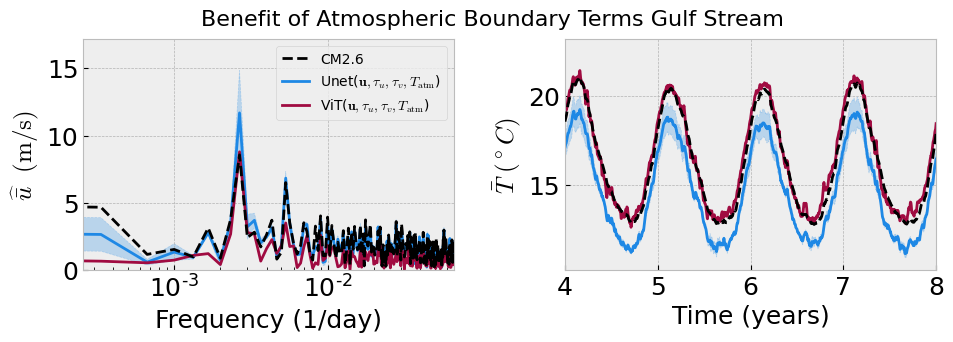

In [13]:
# plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc("axes", titlesize=20)  # fontsize of the axes title
plt.rc("axes", labelsize=18)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=18)  # fontsize of the tick labels
plt.rc("ytick", labelsize=18)  # fontsize of the tick labels
plt.rc("legend", fontsize=10)  # legend fontsize
plt.rc("figure", titlesize=18)


fig, axs = plt.subplots(
    1,
    2,
    figsize=(11, 3),
    gridspec_kw={
        "width_ratios": [1, 1],
        "height_ratios": [1],
        "wspace": 0.3,
        "hspace": 0.5,
    },
)
plot_time_spec(0, 0, True)
plot_mean(1, 2)


region_title = ""

for i in region:
    if region == "Quiescent_Ext":
        region_title = "South Pacific"
    elif region == "Africa_Ext":
        region_title = "African Cape"
    elif i == "_":
        region_title += " "
    elif i == "E":
        break
    else:
        region_title += i
region_title = str(region_title)

fig.suptitle("Benefit of Atmospheric Boundary Terms " + region_title, fontsize=16)

# plt.savefig("/scratch/as15415/Emulation/Figures/Boundary_Figure_Paper_"+region+".png",bbox_inches='tight')

/state/partition1/job-43806392/ipykernel_4023801/237904823.py:27: UserWarning: Attempted to set non-positive left xlim on a log-scaled axis.
Invalid limit will be ignored.
  axs[plt_index].set_xlim([0,freqs[T_plot]])


Text(0.5, 0.98, 'Long-Time Statistics Gulf Stream ')

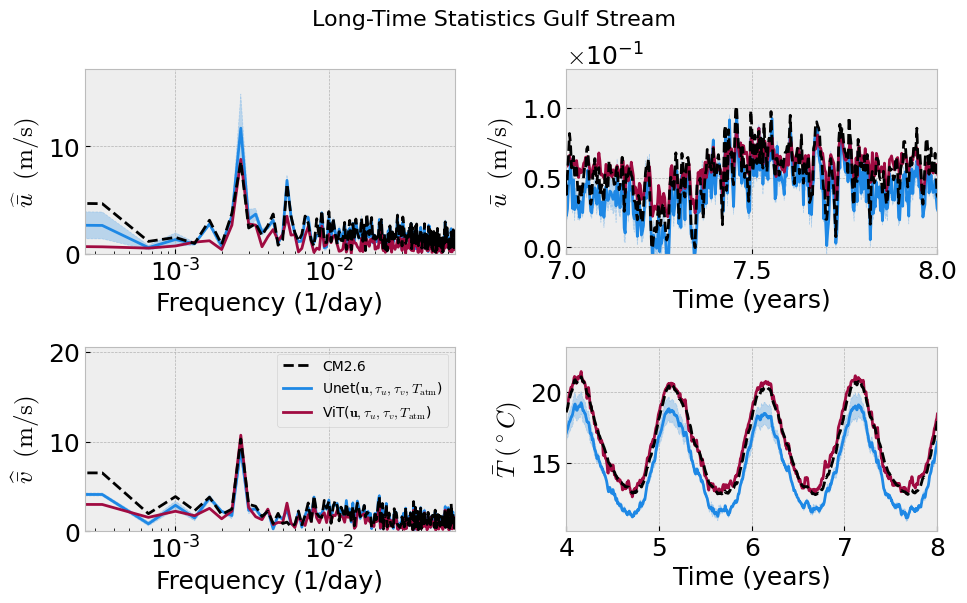

In [14]:
# plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc("axes", titlesize=20)  # fontsize of the axes title
plt.rc("axes", labelsize=18)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=18)  # fontsize of the tick labels
plt.rc("ytick", labelsize=18)  # fontsize of the tick labels
plt.rc("legend", fontsize=10)  # legend fontsize
plt.rc("figure", titlesize=18)


fig, axs = plt.subplots(
    2,
    2,
    figsize=(11, 6),
    gridspec_kw={
        "width_ratios": [1, 1],
        "height_ratios": [1, 1],
        "wspace": 0.3,
        "hspace": 0.5,
    },
)
plot_time_spec((0, 0), 0, False)
plot_mean((0, 1), 0)
plot_time_spec((1, 0), 1)
plot_mean((1, 1), 2)

region_title = ""

for i in region:
    if region == "Quiescent_Ext":
        region_title = "South Pacific"
    elif region == "Africa_Ext":
        region_title = "African Cape"
    elif i == "_":
        region_title += " "
    elif i == "E":
        break
    else:
        region_title += i
region_title = str(region_title)

fig.suptitle("Long-Time Statistics " + region_title, fontsize=16)

# plt.savefig("/scratch/as15415/Emulation/Figures/Long_Time_Comp_Boundary_"+region+".png",bbox_inches='tight')